In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, sys
import json
import torch
import pandas as pd
import numpy as np
SAVE_PATH = '/content/drive/MyDrive/2026-1/NLP/appraisal/nlp-appraisal/data'
REPO_ROOT = os.path.dirname(SAVE_PATH)
sys.path.append(REPO_ROOT)

In [30]:
checkpoint = torch.load(REPO_ROOT + '/checkpoints/best_model_phase2.pt', map_location='cpu')
print(type(checkpoint))
print(len(checkpoint))

<class 'collections.OrderedDict'>
201


In [ ]:
log = pd.read_csv(REPO_ROOT + '/outputs/training_log_1.csv')
print(log)

   epoch  avg_train_loss  avg_val_loss  goal_relevance_rmse  \
0      1        0.017639      0.112773             0.315641   
1      2        0.015330      0.113617             0.317355   
2      3        0.013860      0.109815             0.317266   
3      4        0.012361      0.111618             0.317957   
4      5        0.010836      0.115102             0.328202   

   self_responsblt_rmse  other_responsblt_rmse  chance_responsblt_rmse  \
0              0.331489               0.345313                0.364389   
1              0.320346               0.330120                0.383610   
2              0.325765               0.330146                0.364745   
3              0.324156               0.327979                0.364138   
4              0.329690               0.333071                0.360865   

   goal_support_rmse  predict_conseq_rmse  urgency_rmse  self_control_rmse  \
0           0.306063             0.332673      0.343889           0.332746   
1           0.292081

In [4]:
# Table 8 from Troiano et al. (2023) - RoBERTa-large T->A model RMSE (1-5 scale)
# Mapped to 15 target dimensions
paper_rmse = {
    'goal_relevance':    1.57,
    'self_responsblt':   1.40,
    'other_responsblt':  1.57,
    'chance_responsblt': 1.43,
    'goal_support':      1.33,
    'predict_conseq':    1.50,
    'urgency':           1.43,
    'self_control':      1.35,
    'other_control':     1.36,
    'chance_control':    1.35,
    'accept_conseq':     1.44,
    'social_norms':      1.34,
    'standards':         1.36,
    'attention':         1.27,
    'effort':            1.38,
}

In [5]:
import matplotlib.pyplot as plt

def analyze_training_log(phase_name):
    
    log = pd.read_csv(REPO_ROOT + f'/outputs/training_log_{phase_name}.csv')

    plt.figure(figsize=(10, 5))
    plt.plot(log['epoch'], log['avg_train_loss'], label='Train Loss')
    plt.plot(log['epoch'], log['avg_val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.show()
    print("Best epoch row:")
    best_epoch_row = log.loc[log['avg_val_loss'].idxmin()]
    print(best_epoch_row)
    print("Per-dimension RMSE table for best epoch:")
    rmse_columns = [col for col in log.columns if col.endswith('_rmse')]
    rmse_dict = {col.replace('_rmse', ''): best_epoch_row[col] for col in rmse_columns}
    rmse_df = pd.DataFrame(list(rmse_dict.items()), columns=['Dimension', 'RMSE'])
    return rmse_dict, rmse_df

def compare_to_paper(rmse_dict, paper_rmse_dict):
    comparison_df = pd.DataFrame({
        'dimension': list(rmse_dict.keys()),
        'model_rmse_scaled': [val * 4 for val in rmse_dict.values()],
        'paper_rmse': [paper_rmse_dict[dim] for dim in rmse_dict.keys()],
        'difference': [rmse_dict[dim] * 4 - paper_rmse_dict[dim] for dim in rmse_dict.keys()],      
        'better_than_paper': [rmse_dict[dim] * 4 < paper_rmse_dict[dim] for dim in rmse_dict.keys()]
    })
    # Return two dfs: one df showing dimensions where paper outperforms this model and how much rounded to 4 decimal places and the other comparison_df
    worse_than_paper_df = comparison_df.loc[comparison_df['better_than_paper'] == False, ['dimension', 'difference']].copy()
    worse_than_paper_df['difference'] = worse_than_paper_df['difference'].round(4)
    return worse_than_paper_df, comparison_df

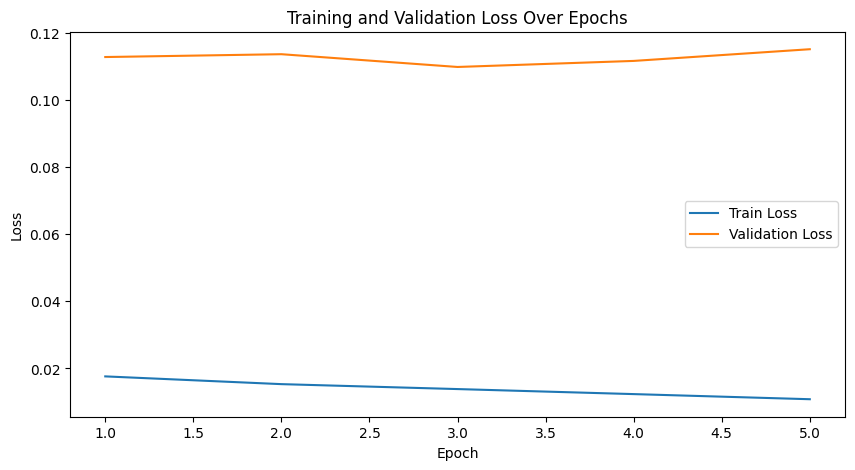

Best epoch row:
epoch                     3.000000
avg_train_loss            0.013860
avg_val_loss              0.109815
goal_relevance_rmse       0.317266
self_responsblt_rmse      0.325765
other_responsblt_rmse     0.330146
chance_responsblt_rmse    0.364745
goal_support_rmse         0.285044
predict_conseq_rmse       0.333440
urgency_rmse              0.337986
self_control_rmse         0.314882
other_control_rmse        0.321206
chance_control_rmse       0.360424
accept_conseq_rmse        0.359123
social_norms_rmse         0.326744
standards_rmse            0.333721
attention_rmse            0.337353
effort_rmse               0.313948
Name: 2, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.31726557), 'self_responsblt': np.float64(0.32576537), 'other_responsblt': np.float64(0.330146), 'chance_responsblt': np.float64(0.36474514), 'goal_support': np.float64(0.28504393), 'predict_conseq': np.float64(0.33343974), 'urgency': np.float64(0.33798596),

In [13]:
# Analyze the first training log
rmse_dict_p1unfrozen, rmse_df = analyze_training_log("phase1_unfrozen")
worse_than_paper_df_p1unfrozen,comparison_df = compare_to_paper(rmse_dict_p1unfrozen, paper_rmse)
print(rmse_dict_p1unfrozen)
print(rmse_df)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_p1unfrozen.values())).round(4) * 4)
print(comparison_df)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_p1unfrozen)

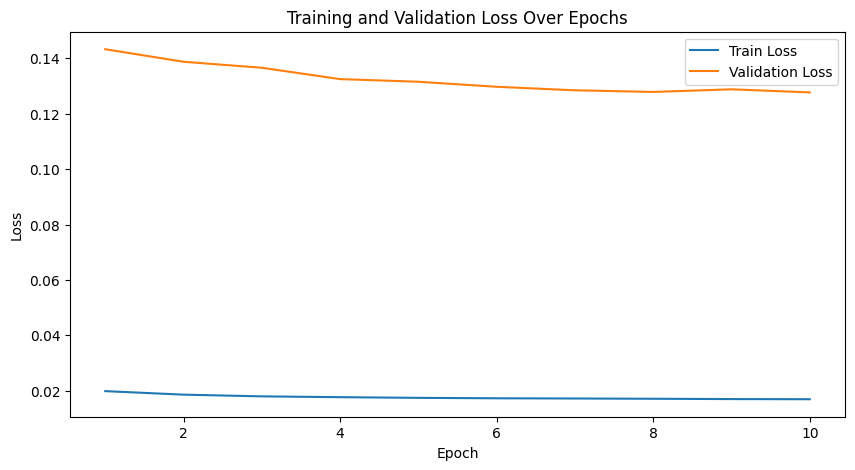

Best epoch row:
epoch                     10.000000
avg_train_loss             0.016932
avg_val_loss               0.127705
goal_relevance_rmse        0.328679
self_responsblt_rmse       0.365837
other_responsblt_rmse      0.381009
chance_responsblt_rmse     0.386849
goal_support_rmse          0.329295
predict_conseq_rmse        0.345295
urgency_rmse               0.356082
self_control_rmse          0.333724
other_control_rmse         0.366864
chance_control_rmse        0.397133
accept_conseq_rmse         0.355965
social_norms_rmse          0.352668
standards_rmse             0.361108
attention_rmse             0.349888
effort_rmse                0.341935
Name: 9, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.32867938), 'self_responsblt': np.float64(0.36583686), 'other_responsblt': np.float64(0.3810087), 'chance_responsblt': np.float64(0.38684863), 'goal_support': np.float64(0.3292946), 'predict_conseq': np.float64(0.34529516), 'urgency': np.fl

In [20]:
# Analyze the first training log again to confirm results are consistent
rmse_dict_p1frozen, rmse_df = analyze_training_log("phase1")
worse_than_paper_df_p1frozen,comparison_df = compare_to_paper(rmse_dict_p1frozen, paper_rmse)
print(rmse_dict_p1frozen)
print(rmse_df)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_p1frozen.values())).round(4) * 4)
print(comparison_df)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_p1frozen)

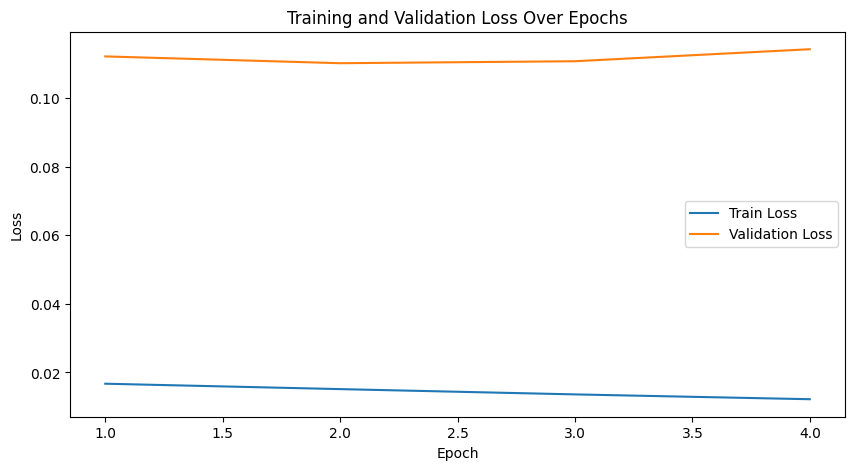

Best epoch row:
epoch                     2.000000
avg_train_loss            0.015161
avg_val_loss              0.110103
goal_relevance_rmse       0.313629
self_responsblt_rmse      0.328150
other_responsblt_rmse     0.336489
chance_responsblt_rmse    0.341846
goal_support_rmse         0.293320
predict_conseq_rmse       0.335845
urgency_rmse              0.347396
self_control_rmse         0.319550
other_control_rmse        0.332964
chance_control_rmse       0.339095
accept_conseq_rmse        0.356692
social_norms_rmse         0.340592
standards_rmse            0.335035
attention_rmse            0.334743
effort_rmse               0.316789
Name: 1, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.31362927), 'self_responsblt': np.float64(0.32815), 'other_responsblt': np.float64(0.33648857), 'chance_responsblt': np.float64(0.34184566), 'goal_support': np.float64(0.2933197), 'predict_conseq': np.float64(0.33584517), 'urgency': np.float64(0.34739563), '

In [21]:
# Analyze the second training log 
rmse_dict_p2, rmse_df = analyze_training_log("phase2")
worse_than_paper_df_p2,comparison_df = compare_to_paper(rmse_dict_p2, paper_rmse)
print(rmse_dict_p2)
print(rmse_df)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_p2   .values())).round(4) * 4)
print(comparison_df)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_p2)

In [27]:
target_dims = [
    'goal_relevance', 'self_responsblt', 'other_responsblt', 'chance_responsblt',
    'goal_support', 'predict_conseq', 'urgency', 'self_control', 'other_control',
    'chance_control', 'accept_conseq', 'social_norms', 'standards', 'attention', 'effort'
]

comparison_full = pd.DataFrame({
    'dimension': target_dims,
    'paper': [paper_rmse[d] for d in target_dims],
    'phase1_unfrozen': [rmse_dict_p1unfrozen[d] * 4 for d in target_dims],
    'phase1_frozen': [rmse_dict_p1frozen[d] * 4 for d in target_dims],
    'phase2': [rmse_dict_p2[d] * 4 for d in target_dims],
})

# Add improvement columns
comparison_full['p1u_vs_paper'] = comparison_full['phase1_unfrozen'] - comparison_full['paper']
comparison_full['p1f_vs_paper'] = comparison_full['phase1_frozen'] - comparison_full['paper']
comparison_full['p2_vs_paper'] = comparison_full['phase2'] - comparison_full['paper']
comparison_full['p2_vs_p1unfrozen'] = comparison_full['phase2'] - comparison_full['phase1_unfrozen']

# Sort by p2_vs_paper to see worst dimensions first
comparison_full = comparison_full.sort_values('p2_vs_p1unfrozen', ascending=False)
print(comparison_full.to_string())

            dimension  paper  phase1_unfrozen  phase1_frozen    phase2  p1u_vs_paper  p1f_vs_paper  p2_vs_paper  p2_vs_p1unfrozen
11       social_norms   1.34         1.306974       1.410672  1.362369     -0.033026      0.070672     0.022369          0.055395
8       other_control   1.36         1.284823       1.467455  1.331856     -0.075177      0.107455    -0.028144          0.047033
6             urgency   1.43         1.351944       1.424329  1.389583     -0.078056     -0.005671    -0.040417          0.037639
4        goal_support   1.33         1.140176       1.317178  1.173279     -0.189824     -0.012822    -0.156721          0.033103
2    other_responsblt   1.57         1.320584       1.524035  1.345954     -0.249416     -0.045965    -0.224046          0.025370
7        self_control   1.35         1.259529       1.334896  1.278198     -0.090471     -0.015104    -0.071802          0.018669
14             effort   1.38         1.255790       1.367738  1.267155     -0.124210     -

In [28]:
comparison_full_md = comparison_full.to_markdown()
print(comparison_full_md)

|    | dimension         |   paper |   phase1_unfrozen |   phase1_frozen |   phase2 |   p1u_vs_paper |   p1f_vs_paper |   p2_vs_paper |   p2_vs_p1unfrozen |
|---:|:------------------|--------:|------------------:|----------------:|---------:|---------------:|---------------:|--------------:|-------------------:|
| 11 | social_norms      |    1.34 |           1.30697 |         1.41067 |  1.36237 |     -0.033026  |     0.0706724  |     0.0223694 |         0.0553954  |
|  8 | other_control     |    1.36 |           1.28482 |         1.46746 |  1.33186 |     -0.0751773 |     0.107455   |    -0.0281442 |         0.047033   |
|  6 | urgency           |    1.43 |           1.35194 |         1.42433 |  1.38958 |     -0.0780562 |    -0.00567096 |    -0.0404175 |         0.0376387  |
|  4 | goal_support      |    1.33 |           1.14018 |         1.31718 |  1.17328 |     -0.189824  |    -0.0128216  |    -0.156721  |         0.0331031  |
|  2 | other_responsblt  |    1.57 |           1.32058 |  

In [31]:
# Average scaled RMSE for each phase
print("Average scaled RMSE for phase 1 unfrozen:", np.mean(list(rmse_dict_p1unfrozen.values())).round(4) * 4)
print("Average scaled RMSE for phase 1 frozen:", np.mean(list(rmse_dict_p1frozen.values())).round(4) * 4)
print("Average scaled RMSE for phase 2:", np.mean(list(rmse_dict_p2.values())).round(4) * 4)
print("Average scaled RMSE of the original paper:", np.mean(list(paper_rmse.values())).round(4))

Average scaled RMSE for phase 1 unfrozen: 1.3232
Average scaled RMSE for phase 1 frozen: 1.4272
Average scaled RMSE for phase 2: 1.326
Average scaled RMSE of the original paper: 1.4053
